In [1]:
#1. Install libraries

!pip install -q datasets transformers accelerate sentencepiece scikit-learn seaborn

In [2]:
#2. Import libraries

import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
# 3. Check GPU

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
# 4. Load Twitter dataset

twitter = load_dataset("tweet_eval", "sentiment")

print(twitter)
print("Train labels:", set(twitter["train"]["label"]))
print("Test labels:", set(twitter["test"]["label"]))

In [ ]:
# 5. Convert Twitter to binary sentiment
# We remove neutral because the task is binary sentiment classification.

def convert_twitter_label(example):
    if example["label"] == 0:
        example["label"] = 0   # negative
    elif example["label"] == 2:
        example["label"] = 1   # positive
    else:
        example["label"] = -1  # neutral, remove later
    return example

twitter_binary = twitter.map(convert_twitter_label)
twitter_binary = twitter_binary.filter(lambda x: x["label"] != -1)

print("Binary train labels:", set(twitter_binary["train"]["label"]))
print("Binary test labels:", set(twitter_binary["test"]["label"]))
print(twitter_binary)

In [6]:
# 6. Select test size

TEST_SIZE = 2000

twitter_test = twitter_binary["test"].select(range(TEST_SIZE))

X_test_twitter = twitter_test["text"]
y_test_twitter = twitter_test["label"]

print("Twitter test size:", len(X_test_twitter))
print(twitter_test.column_names)

Twitter test size: 2000
['text', 'label']


In [ ]:
# 7. Load recent zero-shot DeBERTa model

zero_shot_model = "cross-encoder/nli-deberta-v3-large"

zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model=zero_shot_model,
    device=0 if torch.cuda.is_available() else -1
)

candidate_labels = ["negative", "positive"]

In [8]:
# 8. Prediction function

def predict_zero_shot(texts):
    predictions = []

    for text in tqdm(texts):
        result = zero_shot_classifier(
            text,
            candidate_labels=candidate_labels,
            multi_label=False
        )

        predicted_label = result["labels"][0]

        if predicted_label == "positive":
            predictions.append(1)
        else:
            predictions.append(0)

    return predictions

In [ ]:
# 9. Evaluate zero-shot DeBERTa on overall Twitter

zero_twitter_predictions = predict_zero_shot(X_test_twitter)

zero_twitter_acc = accuracy_score(y_test_twitter, zero_twitter_predictions)
zero_twitter_prec = precision_score(y_test_twitter, zero_twitter_predictions, zero_division=0)
zero_twitter_rec = recall_score(y_test_twitter, zero_twitter_predictions, zero_division=0)
zero_twitter_f1 = f1_score(y_test_twitter, zero_twitter_predictions, zero_division=0)

print("Zero-shot DeBERTa Twitter Accuracy:", zero_twitter_acc)
print("Zero-shot DeBERTa Twitter Precision:", zero_twitter_prec)
print("Zero-shot DeBERTa Twitter Recall:", zero_twitter_rec)
print("Zero-shot DeBERTa Twitter F1:", zero_twitter_f1)

In [ ]:
# 10. Create overall result table

df_overall = pd.DataFrame([{
    "Case": "Overall Twitter",
    "Samples": len(X_test_twitter),
    "Accuracy": zero_twitter_acc,
    "Precision": zero_twitter_prec,
    "Recall": zero_twitter_rec,
    "F1-score": zero_twitter_f1
}])

df_overall

Special Case Testing

In [10]:
# 11. Define helper functions for text categories

def is_short(text):
    return len(text.split()) < 8


def has_slang(text):
    slang_words = [
        "meh", "idk", "smh", "bruh", "ugh", "nah", "yikes",
        "lmao", "rofl", "wtf", "omg",
        "lowkey", "highkey", "deadass", "no cap", "cap",
        "sus", "trash", "fire", "mid",
        "this ain't it", "not it", "big yikes",
        "love that for you", "yeah right", "thanks a lot"
    ]
    text = text.lower()
    return any(word in text for word in slang_words)


def has_negation(text):
    text_lower = text.lower()
    negation_terms = [
        "not", "n't", "never", "no", "nothing", "hardly",
        "barely", "without", "neither", "nor"
    ]
    return any(term in text_lower.split() for term in negation_terms) or "n't" in text_lower


def has_mixed_sentiment(text):
    positive_words = [
        "good", "great", "nice", "love", "amazing",
        "best", "happy", "excellent", "perfect"
    ]
    negative_words = [
        "bad", "worst", "hate", "poor", "terrible",
        "awful", "sad", "trash", "disappointing"
    ]

    text = text.lower()
    return any(p in text for p in positive_words) and any(n in text for n in negative_words)


def has_uncertainty(text):
    uncertain_words = [
        "maybe", "perhaps", "i guess", "kind of",
        "sort of", "not sure", "it depends", "probably"
    ]

    text = text.lower()
    return any(word in text for word in uncertain_words)


def has_sarcasm_like(text):
    sarcasm_phrases = [
        "yeah right", "thanks a lot", "great...",
        "just perfect", "love that for you",
        "what a joke", "as if", "sure"
    ]

    text = text.lower()
    return any(phrase in text for phrase in sarcasm_phrases)


def has_emoji_or_symbol(text):
    emoji_symbols = [
        "😂", "😭", "😡", "😒", "❤️", "💀",
        "🔥", "🙄", "👍", "👎", "!"
    ]

    return any(symbol in text for symbol in emoji_symbols)

In [11]:
#12. Create short, slang, and ambiguous/negation subsets

import random

random.seed(42)

short_idx = [
    i for i, t in enumerate(X_test_twitter)
    if is_short(t)
]

slang_idx = [
    i for i, t in enumerate(X_test_twitter)
    if has_slang(t)
]

amb_idx = [
    i for i, t in enumerate(X_test_twitter)
    if (
        has_negation(t)
        or has_mixed_sentiment(t)
        or has_uncertainty(t)
        or has_sarcasm_like(t)
    )
]

BALANCED_SIZE = min(len(short_idx), len(slang_idx), len(amb_idx))

short_idx_balanced = random.sample(short_idx, BALANCED_SIZE)
slang_idx_balanced = random.sample(slang_idx, BALANCED_SIZE)
amb_idx_balanced = random.sample(amb_idx, BALANCED_SIZE)


X_short = [X_test_twitter[i] for i in short_idx_balanced]
y_short = [y_test_twitter[i] for i in short_idx_balanced]

X_slang = [X_test_twitter[i] for i in slang_idx_balanced]
y_slang = [y_test_twitter[i] for i in slang_idx_balanced]

X_amb = [X_test_twitter[i] for i in amb_idx_balanced]
y_amb = [y_test_twitter[i] for i in amb_idx_balanced]

print("Short sample size:", len(X_short))
print("Slang sample size:", len(X_slang))
print("Ambiguous/Negation sample size:", len(X_amb))

Short sample size: 164
Slang sample size: 164
Ambiguous/Negation sample size: 164


In [12]:
# 13. Evaluate special cases

def evaluate_subset(name, texts, labels):
    if len(texts) == 0:
        return {
            "Case": name,
            "Samples": 0,
            "Accuracy": None,
            "Precision": None,
            "Recall": None,
            "F1-score": None
        }

    preds = predict_zero_shot(texts)

    return {
        "Case": name,
        "Samples": len(texts),
        "Accuracy": accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds, zero_division=0),
        "Recall": recall_score(labels, preds, zero_division=0),
        "F1-score": f1_score(labels, preds, zero_division=0)
    }

special_results = []

special_results.append(evaluate_subset("Short", X_short, y_short))
special_results.append(evaluate_subset("Slang", X_slang, y_slang))
special_results.append(evaluate_subset("Ambiguous/Negation", X_amb, y_amb))

df_special = pd.DataFrame(special_results)
df_special

100%|██████████| 164/164 [00:15<00:00, 10.49it/s]


,Case,Samples,Accuracy,Precision,Recall,F1-score
0,Short,164,0.878049,0.939394,0.869159,0.902913
1,Slang,164,0.914634,0.933333,0.848485,0.888889
2,Ambiguous/Negation,164,0.914634,0.815789,0.815789,0.815789


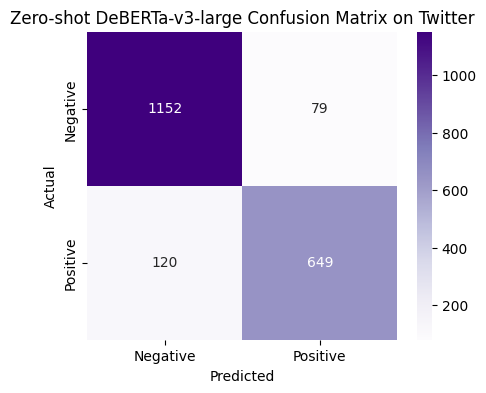

In [14]:
# 14. Plot confusion matrix

cm_zero = confusion_matrix(y_test_twitter, zero_twitter_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_zero,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Zero-shot DeBERTa-v3-large Confusion Matrix on Twitter")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# 16. Create error dataframe

error_rows = []

for i, (text, true_label, pred_label) in enumerate(
    zip(X_test_twitter, y_test_twitter, zero_twitter_predictions)
):
    if true_label != pred_label:
        error_rows.append({
            "index": i,
            "text": text,
            "true_label": "positive" if true_label == 1 else "negative",
            "predicted_label": "positive" if pred_label == 1 else "negative"
        })

df_errors = pd.DataFrame(error_rows)

print("Total errors:", len(df_errors))
df_errors.head(30)

In [ ]:
# 17. Add error category tags

df_errors["short"] = df_errors["text"].apply(is_short)
df_errors["slang"] = df_errors["text"].apply(has_slang)
df_errors["negation"] = df_errors["text"].apply(has_negation)
df_errors["mixed_sentiment"] = df_errors["text"].apply(has_mixed_sentiment)
df_errors["sarcasm_like"] = df_errors["text"].apply(has_sarcasm_like)
df_errors["emoji_symbols"] = df_errors["text"].apply(has_emoji_or_symbol)

df_errors.head(30)

In [ ]:
# 18. Count error categories
error_category_summary = pd.DataFrame({
    "Category": [
        "Short",
        "Slang",
        "Negation",
        "Mixed sentiment",
        "Sarcasm-like",
        "Emoji/symbols"
    ],
    "Error Count": [
        df_errors["short"].sum(),
        df_errors["slang"].sum(),
        df_errors["negation"].sum(),
        df_errors["mixed_sentiment"].sum(),
        df_errors["sarcasm_like"].sum(),
        df_errors["emoji_symbols"].sum()
    ]
})

error_category_summary

In [ ]:
# 19. Show error examples

pd.set_option("display.max_colwidth", 200)

df_errors[
    ["text", "true_label", "predicted_label", "short", "slang", "negation", "mixed_sentiment", "sarcasm_like", "emoji_symbols"]
].head(20)